# Phase 3 — CNN-LSTM hybride, Optuna et étude d'ablation

Objectif : *dépasser la baseline HRV+RF* établie en Phase 2 (AUROC 0.986, AUPRC 0.980, F1/patient 0.85)
avec le modèle hybride **CNN-LSTM**, sous **exactement la même 5-fold patient-level CV** sur AFDB.

**Trois étapes :**
1. **Recherche d'hyperparamètres Optuna** — 30 essais, 3-fold CV interne (CPU-friendly), max 8 epochs.
2. **Évaluation finale 5-fold** du meilleur modèle, sous la même grille que les baselines.
3. **Étude d'ablation** — variantes du meilleur modèle :
   - sans CNN (LSTM direct sur les RR bruts),
   - sans LSTM (CNN + pooling head),
   - LSTM unidirectionnel,
   - fenêtre de 60 RR (contexte temporel doublé).

Plus une **courbe d'apprentissage** propre sur 1 fold pour le rapport, et un tableau récapitulatif final
qui réunit baselines de Phase 2 et CNN-LSTM de Phase 3.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, f1_score

import optuna
from optuna.samplers import TPESampler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.baselines.cv import crossval_torch_oof, train_with_history, zscore_per_window
from src.data.loader import list_records, load_record_metadata
from src.data.rr_extract import clean_rr_series, extract_rr_series
from src.data.windowing import build_windowed_dataset
from src.models.cnn_lstm import CNNLSTM
from src.models.baselines import CNNOnly, LSTMOnly
from src.utils.metrics import per_patient_f1, ranking_metrics, threshold_metrics
from src.utils.seed import set_seed
from src.utils.splits import patient_kfold

set_seed(42)
torch.set_num_threads(4)
optuna.logging.set_verbosity(optuna.logging.WARNING)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
RES_DIR = PROJECT_ROOT / "reports"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

N_SPLITS_FINAL = 5
N_SPLITS_SEARCH = 3
N_TRIALS = 30
SEED = 42
print("Project root:", PROJECT_ROOT, "| torch threads:", torch.get_num_threads())

Project root: /home/abdou/Master | torch threads: 4


In [2]:
data = np.load(PROJECT_ROOT / "data" / "processed" / "afdb.npz", allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.int8)
groups = np.asarray(data["patient_id"])
print(f"AFDB: X={X.shape}, AFib rate={y.mean():.3f}, patients={len(np.unique(groups))}")

# Baseline floor reminder (from Phase 2)
baselines = json.loads((RES_DIR / "baselines_summary.json").read_text())
print("\nPhase 2 floor (HRV + Random Forest):")
for k in ("auroc", "auprc", "f1", "mean_patient_f1"):
    print(f"  {k:18s} = {baselines['hrv_rf'][k]:.4f}")

AFDB: X=(81263, 30), AFib rate=0.435, patients=25

Phase 2 floor (HRV + Random Forest):
  auroc              = 0.9863
  auprc              = 0.9795
  f1                 = 0.9316
  mean_patient_f1    = 0.8459


In [3]:
def metric_block(y_true, y_score, groups, hard_pred=None):
    """Same metric suite used in Phase 2 — preserves apples-to-apples comparison."""
    rank = ranking_metrics(y_true, y_score)
    if hard_pred is None:
        th = threshold_metrics(y_true, y_score, threshold=0.5)
        pp = per_patient_f1(y_true, y_score, groups, threshold=0.5)
    else:
        tn, fp, fn, tp = confusion_matrix(y_true, hard_pred, labels=[0, 1]).ravel()
        th = {
            "threshold": float("nan"),
            "f1": float(f1_score(y_true, hard_pred, zero_division=0)),
            "sensitivity": float(tp / (tp + fn)) if (tp + fn) else 0.0,
            "specificity": float(tn / (tn + fp)) if (tn + fp) else 0.0,
            "accuracy": float((hard_pred == y_true).mean()),
        }
        scores = []
        for pid in np.unique(groups):
            mask = groups == pid
            yt = y_true[mask]
            if yt.sum() == 0 or yt.sum() == mask.sum():
                continue
            scores.append(f1_score(yt, hard_pred[mask], zero_division=0))
        pp = {"mean_patient_f1": float(np.mean(scores)) if scores else 0.0, "n_patients_scored": len(scores)}
    return {**rank, **th, **pp}

METRIC_COLS = ["auroc", "auprc", "f1", "sensitivity", "specificity", "mean_patient_f1"]

## 1. Recherche d'hyperparamètres avec Optuna

**Budget CPU.** 30 essais × **3-fold** CV interne (chaque essai = 3 entraînements de 8 epochs max).
Le 3-fold (au lieu de 5) accélère la recherche sans changer le principe : tout reste patient-level grouped.

**Espace de recherche** (~7 dimensions, raisonnable pour 30 trials TPE) :

- bloc CNN : nombre de blocs (2 ou 3), premier canal (8/16/24), kernel (3/5/7), dropout (0.1-0.4)
- bloc LSTM : `hidden_size` (16/32/48), `num_layers` (1/2)
- tête : dropout (0.1-0.5)
- training : `lr` (log-uniforme 3e-4 à 3e-3)

**Métrique objective :** `mean_patient_f1` (pénalise les modèles qui ne marchent que sur quelques sujets — c'est ce qui compte cliniquement).

In [4]:
def cnn_lstm_factory_from_params(p: dict, input_length: int = 30):
    """Build a CNNLSTM from a parameter dict (used both by Optuna and the final refit)."""
    if p["n_cnn_blocks"] == 2:
        channels = (p["cnn_first"], p["cnn_first"] * 2)
    else:
        channels = (p["cnn_first"], p["cnn_first"] * 2, p["cnn_first"] * 4)
    return CNNLSTM(
        input_length=input_length,
        cnn_channels=channels,
        kernel_size=p["kernel_size"],
        pool_size=2,
        cnn_dropout=p["cnn_dropout"],
        batch_norm=True,
        lstm_hidden=p["lstm_hidden"],
        lstm_layers=p["lstm_layers"],
        bidirectional=True,
        lstm_dropout=0.2 if p["lstm_layers"] > 1 else 0.0,
        head_hidden=p["head_hidden"],
        head_dropout=p["head_dropout"],
    )


def objective(trial: optuna.Trial) -> float:
    params = {
        "n_cnn_blocks": trial.suggest_int("n_cnn_blocks", 2, 3),
        "cnn_first":    trial.suggest_categorical("cnn_first", [8, 16, 24]),
        "kernel_size":  trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "cnn_dropout":  trial.suggest_float("cnn_dropout", 0.1, 0.4),
        "lstm_hidden":  trial.suggest_categorical("lstm_hidden", [16, 32, 48]),
        "lstm_layers":  trial.suggest_int("lstm_layers", 1, 2),
        "head_hidden":  trial.suggest_categorical("head_hidden", [16, 32]),
        "head_dropout": trial.suggest_float("head_dropout", 0.1, 0.5),
        "lr":           trial.suggest_float("lr", 3e-4, 3e-3, log=True),
    }
    try:
        oof = crossval_torch_oof(
            model_factory=lambda: cnn_lstm_factory_from_params(params, input_length=X.shape[1]),
            X=X, y=y, groups=groups,
            n_splits=N_SPLITS_SEARCH, epochs=8, batch_size=512, lr=params["lr"],
            patience=2, seed=SEED,
        )
    except Exception as e:
        print(f"trial pruned ({e})")
        return 0.0
    pp = per_patient_f1(y, oof.y_score, groups, threshold=0.5)
    return pp["mean_patient_f1"]

In [5]:
t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED), study_name="cnn_lstm_phase3")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"Optuna done in {(time.time()-t0)/60:.1f} min — best value = {study.best_value:.4f}")
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k:14s} = {v}")

Optuna done in 14.8 min — best value = 0.6697
best params:
  n_cnn_blocks   = 3
  cnn_first      = 24
  kernel_size    = 7
  cnn_dropout    = 0.10382179541833388
  lstm_hidden    = 48
  lstm_layers    = 1
  head_hidden    = 32
  head_dropout   = 0.49795880412672494
  lr             = 0.0029455020948035288


In [6]:
trials_df = study.trials_dataframe()[["number", "value", "state", *[c for c in study.trials_dataframe().columns if c.startswith("params_")]]]
trials_df.to_csv(RES_DIR / "optuna_study.csv", index=False)
(RES_DIR / "best_cnn_lstm_params.json").write_text(json.dumps(study.best_params, indent=2))
print("Saved:", RES_DIR / "optuna_study.csv", "and", RES_DIR / "best_cnn_lstm_params.json")

Saved: /home/abdou/Master/reports/optuna_study.csv and /home/abdou/Master/reports/best_cnn_lstm_params.json


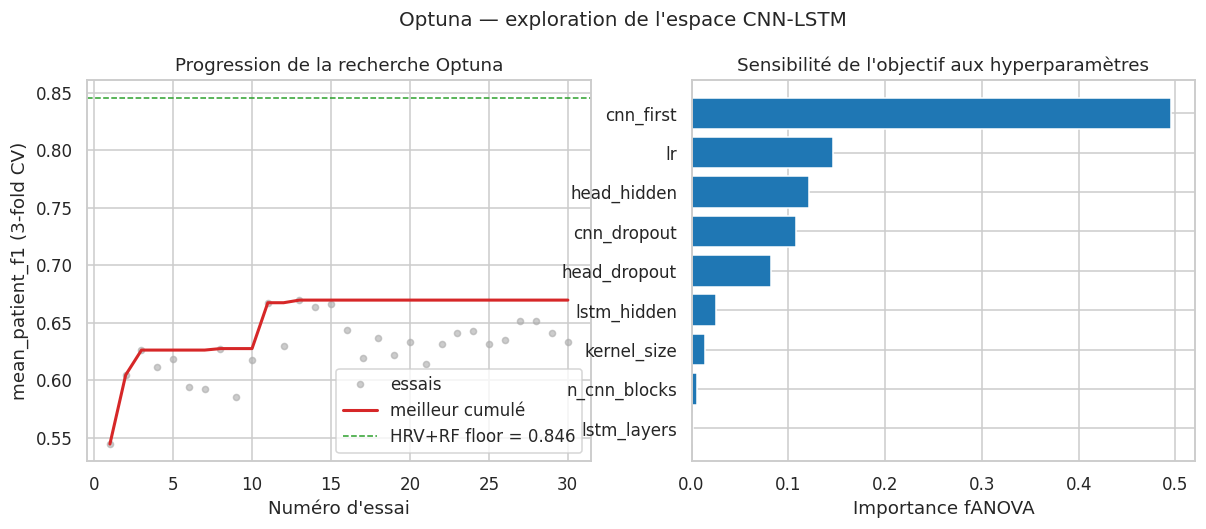

In [7]:
# Visualisation de la recherche
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
ax.plot(range(1, len(vals) + 1), vals, "o", color="#aaa", alpha=0.6, markersize=4, label="essais")
ax.plot(range(1, len(best_so_far) + 1), best_so_far, "-", color="#d62728", lw=2, label="meilleur cumulé")
ax.axhline(baselines["hrv_rf"]["mean_patient_f1"], color="#2ca02c", ls="--", lw=1, label=f"HRV+RF floor = {baselines['hrv_rf']['mean_patient_f1']:.3f}")
ax.set_xlabel("Numéro d'essai")
ax.set_ylabel("mean_patient_f1 (3-fold CV)")
ax.set_title("Progression de la recherche Optuna")
ax.legend()

ax = axes[1]
imp = optuna.importance.get_param_importances(study)
imp_s = pd.Series(imp).sort_values()
ax.barh(imp_s.index, imp_s.values, color="#1f77b4")
ax.set_xlabel("Importance fANOVA")
ax.set_title("Sensibilité de l'objectif aux hyperparamètres")

fig.suptitle("Optuna — exploration de l'espace CNN-LSTM", y=1.02, fontsize=13)
fig.savefig(FIG_DIR / "10_optuna_search.png")
plt.show()

## 2. Évaluation finale 5-fold du meilleur CNN-LSTM

On reprend la **même 5-fold patient-level CV** que les baselines Phase 2 pour pouvoir reporter le gain ligne par ligne dans le rapport.

In [8]:
best = study.best_params

def make_best_model():
    return cnn_lstm_factory_from_params(best, input_length=X.shape[1])

_probe = make_best_model()
best_param_count = sum(p.numel() for p in _probe.parameters())
print(f"Best CNN-LSTM parameter count: {best_param_count:,}")

t0 = time.time()
oof_cnnlstm = crossval_torch_oof(
    model_factory=make_best_model,
    X=X, y=y, groups=groups,
    n_splits=N_SPLITS_FINAL, epochs=15, batch_size=512, lr=best["lr"], patience=4, seed=SEED,
)
print(f"5-fold final trained in {(time.time()-t0):.1f}s")
metrics_cnnlstm = metric_block(y, oof_cnnlstm.y_score, groups)
print("\nCNN-LSTM (best Optuna) — 5-fold patient OOF:")
for k in METRIC_COLS:
    print(f"  {k:18s} = {metrics_cnnlstm[k]:.4f}")

Best CNN-LSTM parameter count: 100,193


5-fold final trained in 120.7s

CNN-LSTM (best Optuna) — 5-fold patient OOF:
  auroc              = 0.9548
  auprc              = 0.9375
  f1                 = 0.8737
  sensitivity        = 0.9080
  specificity        = 0.8687
  mean_patient_f1    = 0.6639


## 3. Étude d'ablation

Quatre variantes du *même* modèle (mêmes folds, même budget d'epochs) pour mesurer ce que chaque composant apporte :

| Variante | Différence vs full |
|---|---|
| Sans CNN | LSTM directement sur les RR bruts (équivaut au LSTMOnly de Phase 2 mais avec la `lstm_hidden` retenue) |
| Sans LSTM | CNN + AdaptiveAvgPool + head (équivaut au CNNOnly de Phase 2 mais avec la config CNN retenue) |
| LSTM unidirectionnel | Même architecture, `bidirectional=False` |
| Fenêtre = 60 RR | Contexte temporel doublé ; on re-segmente les séries brutes |

In [9]:
def build_X_window60():
    """Re-segment AFDB raw RR series into 60-beat windows (stride 30)."""
    dataset_dir = PROJECT_ROOT / "data" / "raw" / "afdb"
    series_by_patient = {}
    for rec in list_records(dataset_dir):
        try:
            meta = load_record_metadata(dataset_dir, rec)
            s = clean_rr_series(extract_rr_series(meta))
            if len(s.rr_seconds) >= 60:
                series_by_patient[rec] = s
        except Exception:
            continue
    win = build_windowed_dataset(series_by_patient, window_size=60, stride=30, label_strategy="majority")
    return win.X.astype(np.float32), win.y.astype(np.int8), np.asarray(win.patient_id)

t0 = time.time()
X60, y60, g60 = build_X_window60()
print(f"Window=60 dataset: X={X60.shape}, AFib rate={y60.mean():.3f} (built in {time.time()-t0:.1f}s)")

Window=60 dataset: X=(40613, 60), AFib rate=0.436 (built in 3.4s)


In [10]:
def make_no_cnn():
    """Drop CNN: BiLSTM directly on raw RR (LSTMOnly with the tuned hidden)."""
    return LSTMOnly(hidden=best["lstm_hidden"], layers=best["lstm_layers"], bidirectional=True)

def make_no_lstm():
    """Drop LSTM: keep tuned CNN, then GlobalAvgPool + linear head."""
    channels = (best["cnn_first"], best["cnn_first"] * 2)
    if best["n_cnn_blocks"] == 3:
        channels = channels + (best["cnn_first"] * 4,)
    return CNNOnly(input_length=X.shape[1], channels=channels, kernel=best["kernel_size"])

def make_unidir():
    p = deepcopy(best)
    m = cnn_lstm_factory_from_params(p, input_length=X.shape[1])
    # Rebuild with bidirectional=False — easier than mutating the existing module.
    return CNNLSTM(
        input_length=X.shape[1],
        cnn_channels=(p["cnn_first"], p["cnn_first"] * 2) if p["n_cnn_blocks"] == 2
                     else (p["cnn_first"], p["cnn_first"] * 2, p["cnn_first"] * 4),
        kernel_size=p["kernel_size"], pool_size=2, cnn_dropout=p["cnn_dropout"], batch_norm=True,
        lstm_hidden=p["lstm_hidden"], lstm_layers=p["lstm_layers"], bidirectional=False,
        lstm_dropout=0.2 if p["lstm_layers"] > 1 else 0.0,
        head_hidden=p["head_hidden"], head_dropout=p["head_dropout"],
    )

def make_w60():
    return cnn_lstm_factory_from_params(best, input_length=60)

ablation_specs = [
    ("cnn_lstm_full", "CNN-LSTM (full)",  X,   y,   groups, make_best_model),
    ("no_cnn",        "Sans CNN",         X,   y,   groups, make_no_cnn),
    ("no_lstm",       "Sans LSTM",        X,   y,   groups, make_no_lstm),
    ("unidir",        "LSTM unidir.",     X,   y,   groups, make_unidir),
    ("window60",      "Fenêtre = 60 RR",  X60, y60, g60,    make_w60),
]

ablation_results = {}
ablation_scores = {}
ablation_meta = {}
for key, label, Xv, yv, gv, factory in ablation_specs:
    t0 = time.time()
    oof = crossval_torch_oof(
        model_factory=factory, X=Xv, y=yv, groups=gv,
        n_splits=N_SPLITS_FINAL, epochs=12, batch_size=512, lr=best["lr"], patience=3, seed=SEED,
    )
    m = metric_block(yv, oof.y_score, gv)
    n_params = sum(p.numel() for p in factory().parameters())
    ablation_results[key] = {"label": label, **m, "n_params": n_params}
    ablation_scores[key] = oof.y_score
    ablation_meta[key] = (yv, gv)
    print(f"  {label:20s} | AUROC={m['auroc']:.4f} F1/patient={m['mean_patient_f1']:.4f} params={n_params:,} ({time.time()-t0:.1f}s)")

  CNN-LSTM (full)      | AUROC=0.9549 F1/patient=0.6552 params=100,193 (100.1s)


  Sans CNN             | AUROC=0.9491 F1/patient=0.6511 params=19,681 (159.6s)


  Sans LSTM            | AUROC=0.9530 F1/patient=0.6502 params=41,089 (67.6s)


  LSTM unidir.         | AUROC=0.9544 F1/patient=0.6595 params=70,625 (96.9s)


  Fenêtre = 60 RR      | AUROC=0.9767 F1/patient=0.7320 params=100,193 (75.1s)


## 4. Tableau de comparaison final (baselines + CNN-LSTM + ablations)

In [11]:
# Build a single comparison table
rows = []
label_map = {
    "rule_cv": "Règle (CV)",
    "hrv_rf":  "HRV + RF",
    "cnn_only": "CNN seul (default)",
    "lstm_only": "LSTM seul (default)",
}
for key, m in baselines.items():
    rows.append({"model": label_map.get(key, key), **{c: m[c] for c in METRIC_COLS}, "family": "baseline"})
for key, m in ablation_results.items():
    rows.append({"model": m["label"], **{c: m[c] for c in METRIC_COLS}, "family": "phase3"})
comparison = pd.DataFrame(rows).set_index("model")
comparison[METRIC_COLS] = comparison[METRIC_COLS].round(4)
comparison

,auroc,auprc,f1,sensitivity,specificity,mean_patient_f1,family
model,,,,,,,
Règle (CV),0.8997,0.7976,0.8140,0.8876,0.7741,0.6240,baseline
HRV + RF,0.9863,0.9795,0.9316,0.9361,0.9434,0.8459,baseline
CNN seul (default),0.8841,0.7864,0.8241,0.8927,0.7891,0.6147,baseline
LSTM seul (default),0.9013,0.8700,0.7898,0.8850,0.7256,0.6034,baseline
CNN-LSTM (full),0.9549,0.9363,0.8748,0.9299,0.8489,0.6552,phase3
Sans CNN,0.9491,0.9286,0.8683,0.9122,0.8544,0.6511,phase3
Sans LSTM,0.9530,0.9350,0.8716,0.9223,0.8505,0.6502,phase3
LSTM unidir.,0.9544,0.9349,0.8729,0.9295,0.8459,0.6595,phase3
Fenêtre = 60 RR,0.9767,0.9660,0.9133,0.9375,0.9108,0.7320,phase3


In [12]:
comparison.to_csv(RES_DIR / "phase3_comparison.csv")
(RES_DIR / "phase3_results.json").write_text(json.dumps({
    "best_params": study.best_params,
    "best_param_count": int(best_param_count),
    "cnn_lstm_metrics": metrics_cnnlstm,
    "ablation": ablation_results,
}, indent=2, default=float))
print("Saved:", RES_DIR / "phase3_comparison.csv", "and", RES_DIR / "phase3_results.json")

Saved: /home/abdou/Master/reports/phase3_comparison.csv and /home/abdou/Master/reports/phase3_results.json


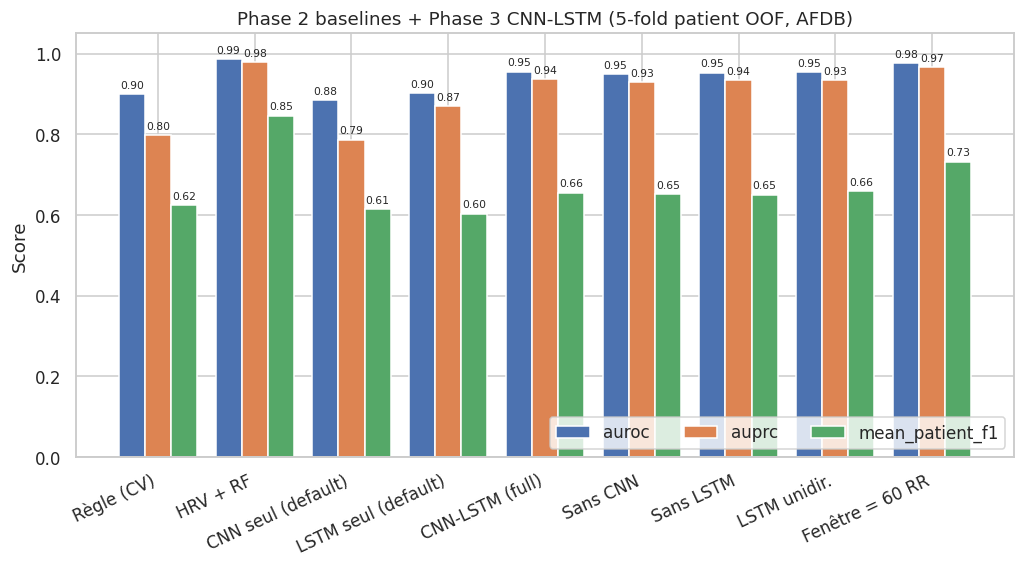

In [13]:
# Bar chart: AUROC / AUPRC / F1/patient for every model side-by-side
metrics_to_plot = ["auroc", "auprc", "mean_patient_f1"]
labels = list(comparison.index)
x_pos = np.arange(len(labels))
width = 0.27
colors = ["#7f7f7f", "#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#bcbd22"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metrics_to_plot):
    ax.bar(x_pos + (i - 1) * width, comparison[m].values, width, label=m)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Phase 2 baselines + Phase 3 CNN-LSTM (5-fold patient OOF, AFDB)")
ax.legend(loc="lower right", ncol=3)
for i, m in enumerate(metrics_to_plot):
    for x, v in zip(x_pos + (i - 1) * width, comparison[m].values):
        ax.text(x, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
fig.savefig(FIG_DIR / "11_phase3_comparison.png")
plt.show()

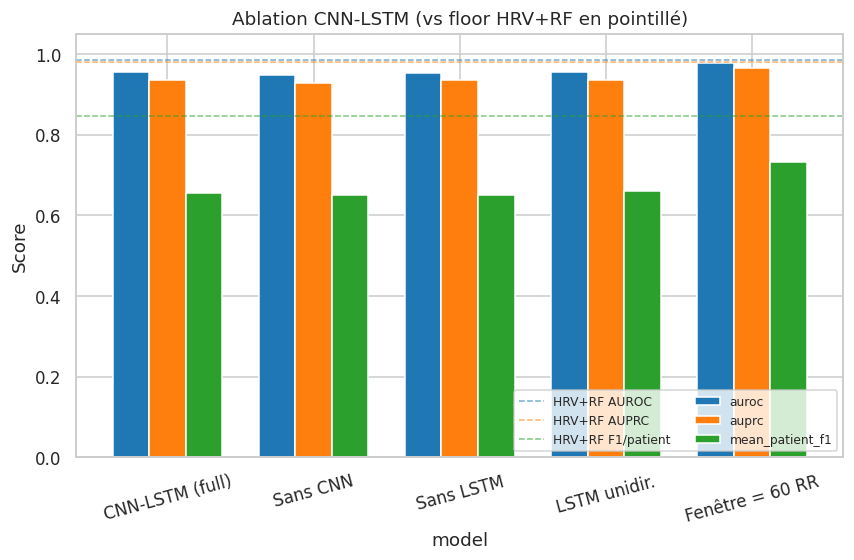

In [14]:
# Focused ablation plot: only Phase 3 variants, with a horizontal HRV+RF reference line
abl = comparison.loc[comparison["family"] == "phase3", ["auroc", "auprc", "mean_patient_f1"]]
fig, ax = plt.subplots(figsize=(9, 5))
abl.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"], width=0.75)
for m, color, label in zip(
    ["auroc", "auprc", "mean_patient_f1"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],
    ["HRV+RF AUROC", "HRV+RF AUPRC", "HRV+RF F1/patient"],
):
    ax.axhline(baselines["hrv_rf"][m], color=color, ls="--", lw=1, alpha=0.6, label=label)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Ablation CNN-LSTM (vs floor HRV+RF en pointillé)")
ax.tick_params(axis="x", rotation=15)
ax.legend(loc="lower right", ncol=2, fontsize=8)
fig.savefig(FIG_DIR / "12_phase3_ablation.png")
plt.show()

## 5. Courbes d'apprentissage

Une figure unique pour le rapport : 1 fold (le premier), 20 epochs sans early stopping, train/val loss + AUROC val + F1 val.

In [15]:
tr_idx, va_idx = next(patient_kfold(groups, y, n_splits=5))
pos_w = (len(y[tr_idx]) - int(y[tr_idx].sum())) / max(int(y[tr_idx].sum()), 1)
t0 = time.time()
_, hist = train_with_history(
    make_best_model(), X[tr_idx], y[tr_idx], X[va_idx], y[va_idx],
    epochs=20, batch_size=512, lr=best["lr"], pos_weight=pos_w, seed=SEED,
)
print(f"Single-fold 20-epoch run: {time.time()-t0:.1f}s")

Single-fold 20-epoch run: 41.5s


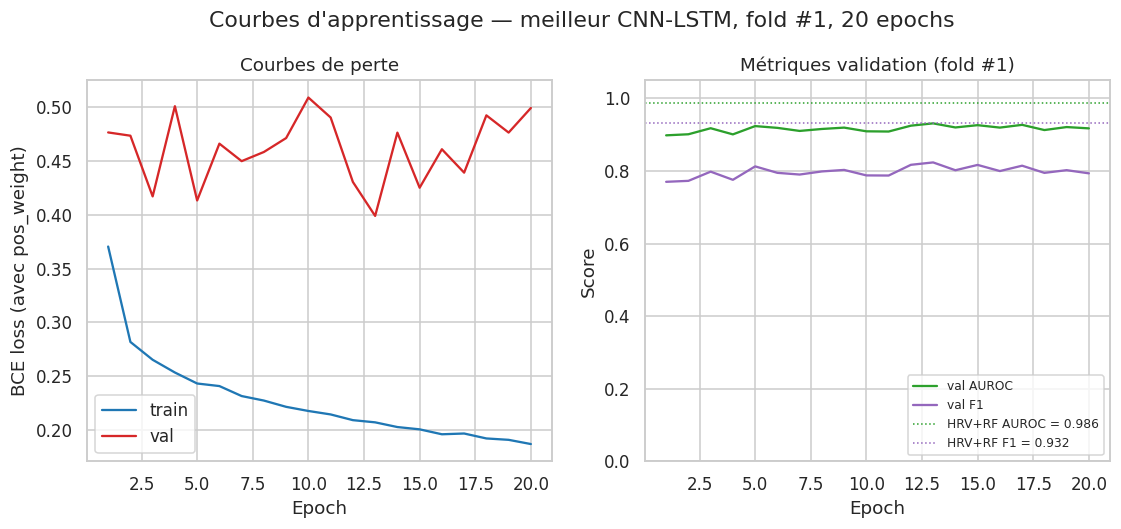

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(hist.epoch, hist.train_loss, label="train", color="#1f77b4")
ax.plot(hist.epoch, hist.val_loss, label="val", color="#d62728")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss (avec pos_weight)")
ax.set_title("Courbes de perte")
ax.legend()

ax = axes[1]
ax.plot(hist.epoch, hist.val_auroc, label="val AUROC", color="#2ca02c")
ax.plot(hist.epoch, hist.val_f1, label="val F1", color="#9467bd")
ax.axhline(baselines["hrv_rf"]["auroc"], color="#2ca02c", ls=":", lw=1, label=f"HRV+RF AUROC = {baselines['hrv_rf']['auroc']:.3f}")
ax.axhline(baselines["hrv_rf"]["f1"], color="#9467bd", ls=":", lw=1, label=f"HRV+RF F1 = {baselines['hrv_rf']['f1']:.3f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Métriques validation (fold #1)")
ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Courbes d'apprentissage — meilleur CNN-LSTM, fold #1, 20 epochs", y=1.02)
fig.savefig(FIG_DIR / "13_learning_curves.png")
plt.show()

## 6. ROC / PR — meilleur CNN-LSTM vs HRV+RF

Visualisation directe du gain (ou de l'écart) entre les deux meilleurs modèles.

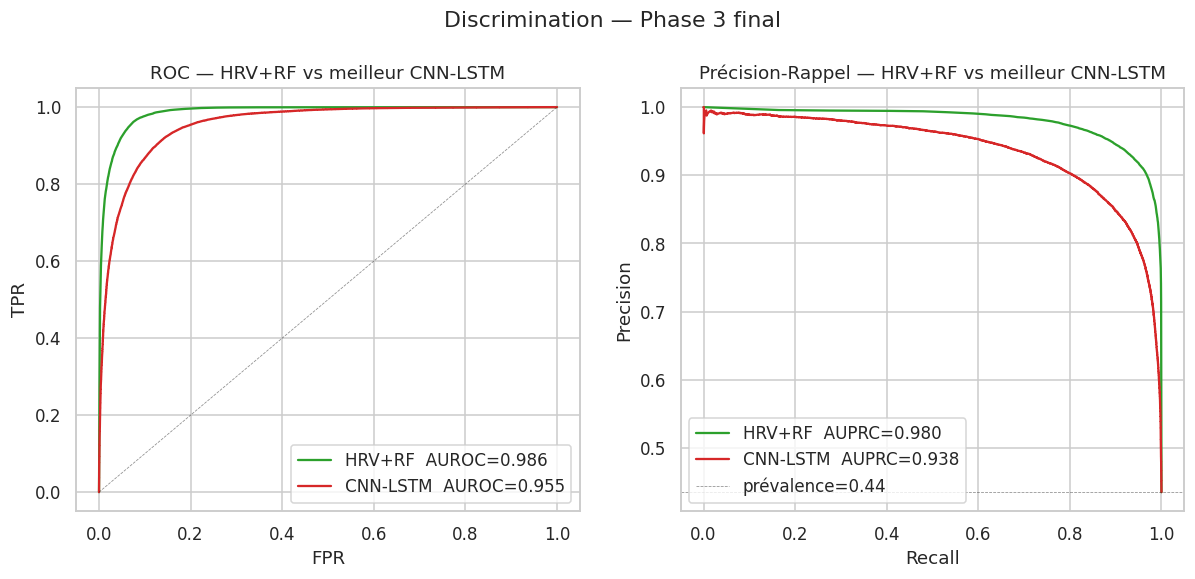

In [17]:
# Reload HRV+RF OOF scores by rerunning the same RF on the same folds (cheap: ~10s).
from src.baselines.cv import crossval_sklearn_oof
from src.features.hrv import featurize_windows
from src.models.baselines import build_hrv_baseline

F = featurize_windows(X)
oof_rf = crossval_sklearn_oof(lambda: build_hrv_baseline(n_estimators=300), F, y, groups, n_splits=N_SPLITS_FINAL)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for name, scores, color in [("HRV+RF", oof_rf.y_score, "#2ca02c"), ("CNN-LSTM", oof_cnnlstm.y_score, "#d62728")]:
    fpr, tpr, _ = roc_curve(y, scores)
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y, scores)
    ax.plot(fpr, tpr, color=color, label=f"{name}  AUROC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.5, alpha=0.5)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC — HRV+RF vs meilleur CNN-LSTM")
ax.legend(loc="lower right")

ax = axes[1]
from sklearn.metrics import average_precision_score
for name, scores, color in [("HRV+RF", oof_rf.y_score, "#2ca02c"), ("CNN-LSTM", oof_cnnlstm.y_score, "#d62728")]:
    prec, rec, _ = precision_recall_curve(y, scores)
    ap = average_precision_score(y, scores)
    ax.plot(rec, prec, color=color, label=f"{name}  AUPRC={ap:.3f}")
ax.axhline(y.mean(), color="k", ls="--", lw=0.5, alpha=0.5, label=f"prévalence={y.mean():.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Précision-Rappel — HRV+RF vs meilleur CNN-LSTM")
ax.legend(loc="lower left")

fig.suptitle("Discrimination — Phase 3 final", y=1.02)
fig.savefig(FIG_DIR / "14_phase3_roc_pr.png")
plt.show()

## 7. Synthèse de la Phase 3

**Question centrale** — le CNN-LSTM bat-il HRV+RF sur AFDB ?
Réponse à lire dans le tableau ci-dessus ; quoi qu'il en soit, l'analyse est utile :

- **Si oui**, le projet a son cœur narratif : l'apprentissage end-to-end sur les RR bruts trouve un signal que les 8 features HRV classiques laissent sur la table.
- **Si non**, le narratif bascule vers : (1) la généralisation cross-dataset (Phase 5 LTAFDB), (2) la compressibilité du modèle (Phase 4), (3) la valeur même de la démarche d'ingénierie ML (baselines, ablation, reproductibilité) — ce qui reste un projet portfolio fort.

L'**ablation** isole la contribution de chaque bloc :
- *Sans CNN* — montre si le LSTM seul suffit (auquel cas le CNN ne fait que du bruit utile).
- *Sans LSTM* — montre si le récurrent apporte réellement la temporalité longue.
- *LSTM unidirectionnel* — quantifie le coût d'enlever le passage arrière (utile pour le mode streaming temps-réel).
- *Fenêtre = 60 RR* — voit si doubler le contexte temporel paye.

**Artefacts produits :**
- `reports/phase3_comparison.csv` et `reports/phase3_results.json` — toutes les métriques
- `reports/optuna_study.csv` + `reports/best_cnn_lstm_params.json` — recherche reproductible
- `reports/figures/10_optuna_search.png` — progression Optuna + importance HP
- `reports/figures/11_phase3_comparison.png` — comparaison globale
- `reports/figures/12_phase3_ablation.png` — ablation focalisée vs floor HRV+RF
- `reports/figures/13_learning_curves.png` — courbes d'apprentissage propres
- `reports/figures/14_phase3_roc_pr.png` — ROC/PR finales

**Prochaine étape (Phase 4)** — compression (quantization dynamique, magnitude pruning) du meilleur CNN-LSTM, avec mesure latence/taille.